## Collaborative Filtering for Movie Recommentations
This notebook develops a recommender system for movies using collaborative filtering system. For this, the dataset ml-small from [DataLens](https://grouplens.org/datasets/movielens/) is used.

In [239]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras

### Data Visualization

In [240]:
df_movies = pd.read_csv('movies.csv')
df_ratings = pd.read_csv('ratings.csv')

In [241]:
display(df_movies.head())
print(df_movies.shape)

display(df_ratings.head())
print(df_ratings.shape)

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


(9742, 3)


,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


(100836, 4)


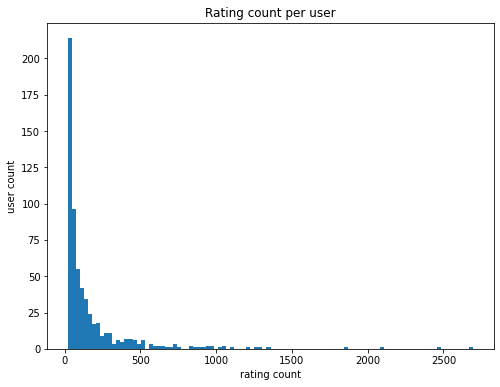

In [242]:
plt.figure(figsize=(8,6))
count_ratings_user = df_ratings.groupby('userId')['movieId'].count()
plt.hist(count_ratings_user.sort_index(), bins=100)
plt.title('Rating count per user')
plt.xlabel('rating count')
plt.ylabel('user count')
plt.show()

100836


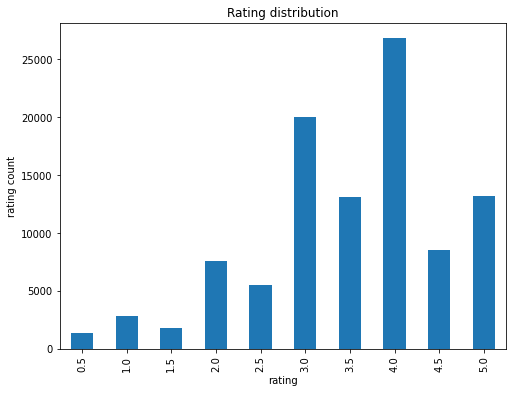

In [258]:
plt.figure(figsize=(8,6))
df_ratings['rating'].value_counts().sort_index().plot(kind='bar')
plt.title('Rating distribution')
plt.xlabel('rating')
plt.ylabel('rating count')
plt.show()

### Data Processing

In [244]:
merged_ratings_movies_df = pd.merge(left=df_ratings, right=df_movies, left_on='movieId', right_on='movieId')
display(merged_ratings_movies_df.head())

,userId,movieId,rating,timestamp,title,genres
0,1,1,4.0,964982703,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,1,3,4.0,964981247,Grumpier Old Men (1995),Comedy|Romance
2,1,6,4.0,964982224,Heat (1995),Action|Crime|Thriller
3,1,47,5.0,964983815,Seven (a.k.a. Se7en) (1995),Mystery|Thriller
4,1,50,5.0,964982931,"Usual Suspects, The (1995)",Crime|Mystery|Thriller


In [245]:
# Clean dataframe
merged_ratings_movies_trunc_df = merged_ratings_movies_df.drop(columns=['rating', 'userId', 'timestamp', 'genres']).drop_duplicates(subset='movieId')

# Calculate mean rating and number of ratings
avg_rating = merged_ratings_movies_df.groupby('movieId')['rating'].agg('mean')
count_rating = merged_ratings_movies_df.groupby('movieId')['rating'].count()

# Include mean rating and number of ratings in the movie summary
movie_summary_df = pd.merge(left=avg_rating, right=count_rating, left_on='movieId', right_on='movieId')
movie_summary_df = movie_summary_df.rename(columns={"rating_x": "mean rating", "rating_y": "number of ratings"})
movie_summary_df = pd.merge(left=movie_summary_df, right=merged_ratings_movies_trunc_df, left_on='movieId', right_on='movieId')

# Sort and filter the movie summary
filter=(movie_summary_df["number of ratings"] > 15)
sorted_avg = movie_summary_df.loc[filter].sort_values(by='mean rating', ascending=False).reset_index(drop=True)
display(sorted_avg[:15])

,movieId,mean rating,number of ratings,title
0,1104,4.475000,20,"Streetcar Named Desire, A (1951)"
1,318,4.429022,317,"Shawshank Redemption, The (1994)"
2,922,4.333333,27,Sunset Blvd. (a.k.a. Sunset Boulevard) (1950)
3,3468,4.333333,18,"Hustler, The (1961)"
4,3435,4.323529,17,Double Indemnity (1944)
5,898,4.310345,29,"Philadelphia Story, The (1940)"
6,1209,4.305556,18,Once Upon a Time in the West (C'era una volta ...
7,1204,4.300000,45,Lawrence of Arabia (1962)
8,475,4.300000,25,In the Name of the Father (1993)
9,246,4.293103,29,Hoop Dreams (1994)


In [246]:
# Remove unnecessary information
movie_rating_trunc_df = merged_ratings_movies_df.drop(columns=['timestamp','title','genres'])

# Include ratings of new user with userId 0
r1 = {'userId':0, 'movieId':356, 'rating':4.0}     #Forrest Gump (1994)
r2 = {'userId':0, 'movieId':318, 'rating':5.0}     #Shawshank Redemption, The (1994)
r3 = {'userId':0, 'movieId':296	, 'rating':4.0}    #Pulp Fiction (1994)
r4 = {'userId':0, 'movieId':2571, 'rating':4.5}    #Matrix, The (1999)
r5 = {'userId':0, 'movieId':260	, 'rating':5.0}    #Star Wars: Episode IV - A New Hope (1977)
r6 = {'userId':0, 'movieId':527, 'rating':4.5}     #Schindler's List (1993)
r7 = {'userId':0, 'movieId':1, 'rating':3.0}       #Toy Story (1995)
r8 = {'userId':0, 'movieId':2959, 'rating':3.5}    #Fight Club (1999)
r9 = {'userId':0, 'movieId':1196, 'rating':5.0}    #Star Wars: Episode V - The Empire Strikes Back
r10 = {'userId':0, 'movieId':858, 'rating':5.0}    #Godfather
r11 = {'userId':0, 'movieId':1221, 'rating':4.5}   #Godfather: Part II, The (1974)
r12 = {'userId':0, 'movieId':93840, 'rating':1.5}  #Cabin in the Woods, The (2012)
r13 = {'userId':0, 'movieId':63992, 'rating':1.5}  #Twilight (2008)
r14 = {'userId':0, 'movieId':4973, 'rating':1.0}   #Amelie (Fabuleux destin d'Amélie Poulain, Le) (2001)
r15 = {'userId':0, 'movieId':1270, 'rating':5.0}   #Back to the Future (1985)
r16 = {'userId':0, 'movieId':91500, 'rating':5.0}  #The Hunger Games (2012)
new_user_ratings_df = pd.DataFrame([r1, r2, r3, r4, r5, r6, r7, r8, r9, r10, r11, r12, r13, r14, r15, r16])

movie_rating_trunc_df = pd.concat([new_user_ratings_df ,movie_rating_trunc_df.loc[:]]).reset_index(drop=True)
display(movie_rating_trunc_df.head())

,userId,movieId,rating
0,0,356,4.0
1,0,318,5.0
2,0,296,4.0
3,0,2571,4.5
4,0,260,5.0


In [ ]:
R_df = movie_rating_trunc_df.pivot_table(index='movieId', columns='userId', aggfunc=lambda x: 1, fill_value=0)
print(R_df.shape)
display(R_df.head())

(9724, 611)


rating                                      ...                      \
userId     0   1   2   3   4   5   6   7   8   9    ... 601 602 603 604 605   
movieId                                             ...                       
1            1   1   0   0   0   1   0   1   0   0  ...   1   0   1   1   1   
2            0   0   0   0   0   0   1   0   1   0  ...   0   1   0   1   1   
3            0   1   0   0   0   0   1   0   0   0  ...   0   0   0   0   0   
4            0   0   0   0   0   0   1   0   0   0  ...   0   0   0   0   0   
5            0   0   0   0   0   0   1   0   0   0  ...   0   0   0   1   0   

                             
userId  606 607 608 609 610  
movieId                      
1         1   1   1   1   1  
2         0   0   1   0   0  
3         0   0   1   0   0  
4         0   0   0   0   0  
5         0   0   0   0   0  

[5 rows x 611 columns]

In [248]:
Y_df = movie_rating_trunc_df.pivot_table(index='movieId', columns='userId', values='rating')
Y_df = Y_df.fillna(0) # fill unrated movies with 0 values
display(Y_df.head())

userId,0,1,2,3,4,5,6,7,8,9,...,601,602,603,604,605,606,607,608,609,610
movieId,,,,,,,,,,,,,,,,,,,,,
1,3.0,4.0,0.0,0.0,0.0,4.0,0.0,4.5,0.0,0.0,...,4.0,0.0,4.0,3.0,4.0,2.5,4.0,2.5,3.0,5.0
2,0.0,0.0,0.0,0.0,0.0,0.0,4.0,0.0,4.0,0.0,...,0.0,4.0,0.0,5.0,3.5,0.0,0.0,2.0,0.0,0.0
3,0.0,4.0,0.0,0.0,0.0,0.0,5.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,3.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,0.0,0.0,0.0,0.0,0.0,0.0,5.0,0.0,0.0,0.0,...,0.0,0.0,0.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0


### Collaborative Filtering Algorithm

In [249]:
R = np.transpose(R_df.to_numpy())
Y = np.transpose(Y_df.to_numpy())

In [250]:
def cost_fcn_mse(X, W, b, Y, R, lambda_):
    j = (tf.linalg.matmul(tf.transpose(W), X) + b - Y)*R
    J = 0.5 * tf.reduce_sum(j**2) + (lambda_/2) * (tf.reduce_sum(X**2) + tf.reduce_sum(W**2))
    return J

In [251]:
feature_count = 100
movie_count = Y.shape[1]
user_count = Y.shape[0]
tf.random.set_seed(1234) # for reproducible results
W = tf.Variable(tf.random.normal((feature_count, user_count),dtype=tf.float64),  name='W')
X = tf.Variable(tf.random.normal((feature_count, movie_count),dtype=tf.float64),  name='X')
b = tf.Variable(tf.random.normal((user_count, 1), dtype=tf.float64), name='b')

optimizer = keras.optimizers.Adam(learning_rate=1e-1)
print(W.shape, X.shape)
print(b.shape)
print(Y.shape)

(100, 611) (100, 9724)
(611, 1)
(611, 9724)


In [252]:
# Normalize the movie ratings
Y_mean = (np.sum(Y*R,axis=0)/(np.sum(R, axis=0)+1e-12)).reshape(1,-1)
Y_norm = Y - np.multiply(Y_mean, R) 

In [253]:
no_iterations = 300
lambda_ = 1 # regularization parameter

In [254]:
# Perform autodiff and train the algorithm
for step in range(no_iterations):
    with tf.GradientTape() as tape:
        cost_value = cost_fcn_mse(X, W, b, Y_norm, R, lambda_)

    gradients = tape.gradient( cost_value, [X,W,b] )

    optimizer.apply_gradients( zip(gradients, [X,W,b]) )

    if step % 40 == 0:
        print(f"Training loss at step {step}: {cost_value:0.1f}")

Training loss at step 0: 5598892.0
Training loss at step 40: 107958.4
Training loss at step 80: 30572.3
Training loss at step 120: 13707.9
Training loss at step 160: 8240.4
Training loss at step 200: 6126.6
Training loss at step 240: 5204.1
Training loss at step 280: 4755.8


### Movie Rating Predictions

In [ ]:
prediction = np.matmul(np.transpose(W.numpy()), X.numpy()) + b.numpy()

prediction_restored = prediction + Y_mean

prediction_user0 = prediction_restored[0,:]
pred_df = pd.DataFrame(prediction_user0, index=Y_df.index)
pred_df = pred_df.rename(columns={0: "predicted rating"})

(611, 9724)


In [256]:
ratings_pred_df = pd.merge(left=movie_summary_df, right=pred_df, left_on='movieId', right_on='movieId')
ratings_pred_df = ratings_pred_df.reindex(columns=["movieId", "title", "number of ratings", "mean rating", "predicted rating"])

ratings_pred_orig_df = pd.merge(left=ratings_pred_df, right=new_user_ratings_df, left_on='movieId', right_on='movieId').drop(columns=['userId'])
ratings_pred_orig_df = ratings_pred_orig_df.style.set_caption("Predicted and original ratings of newly added user")
ratings_pred_orig_df.format(precision=2)
display(ratings_pred_orig_df)

print('\n')
ratings_pred_rec_df = pd.merge(left=ratings_pred_df, right=new_user_ratings_df, how='outer', left_on='movieId', right_on='movieId')
ratings_pred_rec_df = ratings_pred_rec_df.loc[lambda x: x.rating.isnull()].drop(columns=['rating', 'userId'])
filter=(ratings_pred_rec_df["number of ratings"] > 10)
ratings_pred_rec_df = ratings_pred_rec_df.loc[filter].sort_values(by='predicted rating', ascending=False).reset_index(drop=True)
ratings_pred_rec_df = ratings_pred_rec_df[:10]
ratings_pred_rec_df = ratings_pred_rec_df.style.set_caption("Suggested movies for newly added user")
ratings_pred_rec_df.format(precision=2)
display(ratings_pred_rec_df)

,movieId,title,number of ratings,mean rating,predicted rating,rating
0,1,Toy Story (1995),215,3.92,2.98,3.00
1,260,Star Wars: Episode IV - A New Hope (1977),251,4.23,4.97,5.00
2,296,Pulp Fiction (1994),307,4.20,3.93,4.00
3,318,"Shawshank Redemption, The (1994)",317,4.43,4.97,5.00
4,356,Forrest Gump (1994),329,4.16,3.93,4.00
5,527,Schindler's List (1993),220,4.22,4.48,4.50
6,858,"Godfather, The (1972)",192,4.29,4.94,5.00
7,1196,Star Wars: Episode V - The Empire Strikes Back (1980),211,4.22,4.97,5.00
8,1221,"Godfather: Part II, The (1974)",129,4.26,4.42,4.50
9,1270,Back to the Future (1985),171,4.04,4.93,5.00


,movieId,title,number of ratings,mean rating,predicted rating
0,1210,Star Wars: Episode VI - Return of the Jedi (1983),196,4.14,4.66
1,1136,Monty Python and the Holy Grail (1975),136,4.16,4.48
2,50,"Usual Suspects, The (1995)",204,4.24,4.18
3,58559,"Dark Knight, The (2008)",149,4.24,4.18
4,1219,Psycho (1960),83,4.04,4.17
5,1242,Glory (1989),41,4.17,4.16
6,1356,Star Trek: First Contact (1996),91,3.88,4.14
7,3147,"Green Mile, The (1999)",111,4.15,4.11
8,3451,Guess Who's Coming to Dinner (1967),11,4.55,4.08
9,1198,Raiders of the Lost Ark (Indiana Jones and the Raiders of the Lost Ark) (1981),200,4.21,4.07
